G shape: (12, 23)
H shape: (11, 23)
rank(G): 12
Syndromes in table: 2048 (expected 2048)
         p    quantum_sim         theory
------------------------------------------
  1.00e-03      0.000e+00      8.721e-09
  1.93e-03      0.000e+00      1.195e-07
  3.73e-03      0.000e+00      1.615e-06
  7.20e-03      0.000e+00      2.129e-05
  1.39e-02      1.000e-03      2.672e-04
  2.68e-02      3.500e-03      3.048e-03
  5.18e-02      3.550e-02      2.892e-02
  1.00e-01      1.885e-01      1.927e-01


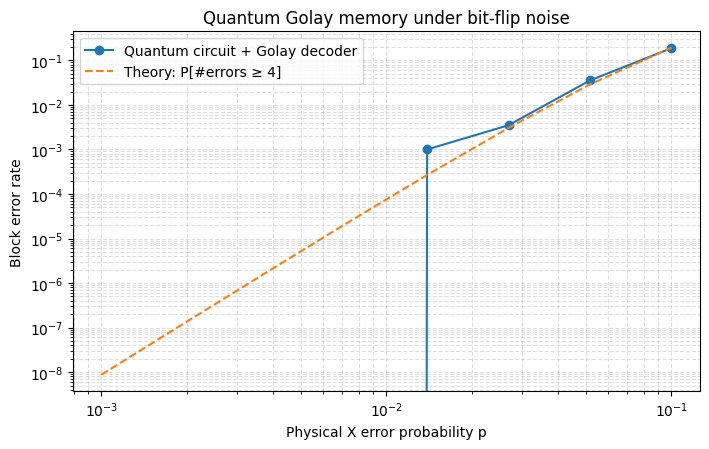

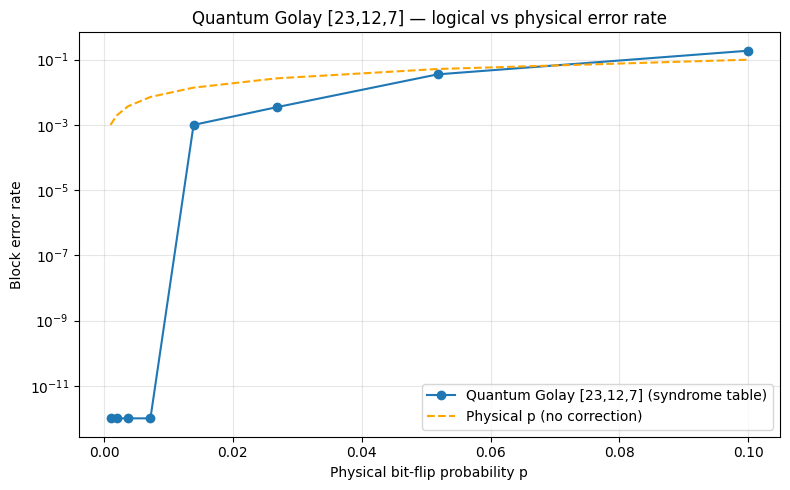

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import stim


from itertools import combinations
import matplotlib.pyplot as plt

def rref_mod2(a: np.ndarray):
    """Row-reduced echelon form over GF(2)."""
    a = (a.copy() & 1).astype(np.uint8)
    rows, cols = a.shape
    pivot_cols = []
    r = 0

    for c in range(cols):
        pivot = None
        for rr in range(r, rows):
            if a[rr, c]:
                pivot = rr
                break
        if pivot is None:
            continue

        if pivot != r:
            a[[r, pivot]] = a[[pivot, r]]

        for rr in range(rows):
            if rr != r and a[rr, c]:
                a[rr] ^= a[r]

        pivot_cols.append(c)
        r += 1
        if r == rows:
            break

    return a, pivot_cols


def build_golay23_matrices():
    """
    Build a systematic generator matrix G (12x23) and parity-check matrix H (11x23)
    for the binary Golay code (23,12,7).

    We start from the cyclic generator polynomial:
    g(x) = 1 + x + x^5 + x^6 + x^7 + x^9 + x^11.
    """
    # Coefficients from x^0 to x^11.
    g_poly = np.array([1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1], dtype=np.uint8)

    # Cyclic generator matrix: rows are x^i * g(x), i=0..11.
    g_cyclic = np.zeros((12, 23), dtype=np.uint8)
    for i in range(12):
        g_cyclic[i, i:i + len(g_poly)] = g_poly

    # Convert to systematic form [I | P].
    g_sys, pivots = rref_mod2(g_cyclic)
    assert pivots == list(range(12)), "Unexpected pivot structure for Golay G."

    p_block = g_sys[:, 12:]
    h = np.concatenate([p_block.T, np.eye(11, dtype=np.uint8)], axis=1)

    # Orthogonality check: G * H^T = 0 over GF(2).
    assert np.all((g_sys @ h.T) % 2 == 0), "G*H^T != 0"

    return g_poly, g_sys, h


GOLAY23_POLY, GOLAY23_G, GOLAY23_H = build_golay23_matrices()

print('G shape:', GOLAY23_G.shape)
print('H shape:', GOLAY23_H.shape)
print('rank(G):', np.linalg.matrix_rank(GOLAY23_G.astype(float)))



def golay23_encode(message_bits) -> np.ndarray:
    """Encode 12 message bits into a 23-bit Golay codeword."""
    m = np.array(message_bits, dtype=np.uint8).reshape(-1)
    if m.size != 12:
        raise ValueError(f'Expected 12 message bits, got {m.size}.')
    return (m @ GOLAY23_G) % 2


def build_golay23_syndrome_table():
    """Map each syndrome to a minimum-weight error pattern (weight <= 3)."""
    table = {}
    n = GOLAY23_H.shape[1]

    for w in range(4):  # 0,1,2,3
        for pos in combinations(range(n), w):
            e = np.zeros(n, dtype=np.uint8)
            if w:
                e[list(pos)] = 1
            s = tuple((GOLAY23_H @ e) % 2)
            # Keep first entry (iterating by increasing weight gives minimum weight).
            if s not in table:
                table[s] = e

    return table


GOLAY23_SYNDROME_TABLE = build_golay23_syndrome_table()
print('Syndromes in table:', len(GOLAY23_SYNDROME_TABLE), '(expected 2048)')


def golay23_decode(received_bits, return_codeword=False):
    """
    Decode a 23-bit received word with bounded-distance syndrome decoding.

    Returns:
      - message (12 bits) if return_codeword=False
      - (message, corrected_codeword, estimated_error) otherwise
    """
    r = np.array(received_bits, dtype=np.uint8).reshape(-1)
    if r.size != 23:
        raise ValueError(f'Expected 23 received bits, got {r.size}.')

    syndrome = tuple((GOLAY23_H @ r) % 2)
    e_hat = GOLAY23_SYNDROME_TABLE.get(syndrome)
    if e_hat is None:
        raise RuntimeError('Syndrome not found in decoder table.')

    c_hat = r ^ e_hat
    m_hat = c_hat[:12]

    if return_codeword:
        return m_hat, c_hat, e_hat
    return m_hat


def golay23_quantum_x_memory_circuit(p: float) -> stim.Circuit:
    """
    Quantum circuit implementing one noisy memory round for the (23,12,7) Golay code
    against X errors, with syndrome extraction from H.
    """
    h = GOLAY23_H
    n_data = 23
    n_check = 11

    data = list(range(n_data))
    anc = list(range(n_data, n_data + n_check))

    c = stim.Circuit()

    # Initialize data and ancillas in |0>.
    c.append('R', data + anc)

    # Bit-flip noise on data (biased-noise setting where X dominates).
    c.append('X_ERROR', data, p)

    # Measure Z-parity checks from H using ancillas.
    # For each row j of H: syndrome bit s_j = sum_i H[j,i] * e_i (mod 2).
    for j in range(n_check):
        a = anc[j]
        support = [i for i in range(n_data) if h[j, i] == 1]
        for q in support:
            c.append('CX', [q, a])
        c.append('M', [a])

    # Final Z-basis measurement of data qubits.
    c.append('M', data)

    return c


def golay23_quantum_decode_shot(sample: np.ndarray):
    """
    Decode one shot from the quantum circuit samples.

    sample format:
      first 11 bits  -> stabilizer outcomes (syndrome)
      next 23 bits   -> data Z measurements
    """
    syndrome = tuple(int(b) for b in sample[:11])
    data_meas = np.array(sample[11:], dtype=np.uint8)

    e_hat = GOLAY23_SYNDROME_TABLE[syndrome]
    corrected = data_meas ^ e_hat
    m_hat = corrected[:12]  # systematic form: first 12 bits are message bits
    return m_hat, corrected, e_hat


def golay23_quantum_block_error_rate(p: float, shots: int = 20000) -> float:
    """
    Block failure rate for the quantum memory circuit.
    We prepare the all-zero codeword, so decoding fails if any decoded message bit is 1.
    """
    c = golay23_quantum_x_memory_circuit(p)
    samples = c.compile_sampler().sample(shots=shots)

    failures = 0
    for sample in samples:
        m_hat, _, _ = golay23_quantum_decode_shot(sample)
        if np.any(m_hat):
            failures += 1

    return failures / shots



def golay23_theory_block_fail(p: float) -> float:
    """Theoretical block-failure probability for t=3 correction on BSC(p)."""
    return 1 - sum(math.comb(23, i) * (p ** i) * ((1 - p) ** (23 - i)) for i in range(4))

# --- Single simulation run ---
ps_q = np.logspace(-3, -1, 8)
shots = 2_000

quantum_bler = []
theory_bler = []

print(f"{'p':>10s}   {'quantum_sim':>12s}   {'theory':>12s}")
print("-" * 42)
for p in ps_q:
    q_ber = golay23_quantum_block_error_rate(float(p), shots=shots)
    t_ber = golay23_theory_block_fail(float(p))
    quantum_bler.append(q_ber)
    theory_bler.append(t_ber)
    print(f"{p:10.2e}   {q_ber:12.3e}   {t_ber:12.3e}")

# --- Plot 1: Quantum sim vs Theory ---
fig1, ax1 = plt.subplots(figsize=(7.2, 4.6))
ax1.loglog(ps_q, quantum_bler, 'o-', label='Quantum circuit + Golay decoder')
ax1.loglog(ps_q, theory_bler, '--', label='Theory: P[#errors ≥ 4]')
ax1.set_xlabel('Physical X error probability p')
ax1.set_ylabel('Block error rate')
ax1.set_title('Quantum Golay memory under bit-flip noise')
ax1.grid(True, which='both', ls='--', alpha=0.4)
ax1.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Logical vs Physical (with reference line) ---
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.semilogy(ps_q, [max(x, 1e-12) for x in quantum_bler], 'o-', label='Quantum Golay [23,12,7] (syndrome table)')
ax2.semilogy(ps_q, ps_q, '--', color='orange', label='Physical p (no correction)')
ax2.set_xlabel('Physical bit-flip probability p')
ax2.set_ylabel('Block error rate')
ax2.set_title('Quantum Golay [23,12,7] — logical vs physical error rate')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()